# CDMX antes, durante y después del COVID-19
## Notebook 01 — Limpieza Datasets

### Limpiando el dataset de los semaforos

In [1]:
from pathlib import Path
import pandas as pd
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
df = pd.read_csv(RAW / "semaforo" / "semaforos_federal.csv")
cdmx = df[df["estado"] == "Ciudad de México"]
cdmx

,estado,2020-W22,2020-W23,2020-W24,2020-W25,2020-W26,2020-W27,2020-W28,2020-W29,2020-W30,...,2023-W15,2023-W16,2023-W17,2023-W18,2023-W19,2023-W20,2023-W21,2023-W22,2023-W23,2023-W24
6,Ciudad de México,rojo,rojo,rojo,rojo,naranja,naranja,naranja,naranja,naranja,...,verde,verde,verde,verde,verde,verde,verde,verde,verde,verde


In [2]:
largo = cdmx.melt(id_vars="estado", var_name="semana", value_name="color")
largo["fecha"] = pd.to_datetime(largo["semana"] + "-1", format="%G-W%V-%u")
largo

,estado,semana,color,fecha
0,Ciudad de México,2020-W22,rojo,2020-05-25
1,Ciudad de México,2020-W23,rojo,2020-06-01
2,Ciudad de México,2020-W24,rojo,2020-06-08
3,Ciudad de México,2020-W25,rojo,2020-06-15
4,Ciudad de México,2020-W26,naranja,2020-06-22
...,...,...,...,...
153,Ciudad de México,2023-W20,verde,2023-05-15
154,Ciudad de México,2023-W21,verde,2023-05-22
155,Ciudad de México,2023-W22,verde,2023-05-29
156,Ciudad de México,2023-W23,verde,2023-06-05


In [3]:
largo.isna().sum()

estado    0
semana    0
color     0
fecha     0
dtype: int64

In [4]:
INTERIM = RAIZ / "data" / "interim"
largo.to_csv(INTERIM / "semaforo_cdmx_semana.csv", index=False, encoding="utf-8-sig")

---
## Datasets limpiados con scripts (FGJ y Metrobús)

Las fuentes grandes se limpian con scripts de Python en `src/clean/`, para que la limpieza sea **reproducible**: cualquiera puede volver a generarla desde `data/raw/`. Cada script:
1. Lee los archivos originales de `data/raw/` (nunca los modifica).
2. Aplica los pasos de limpieza y documenta cuántos registros afecta cada uno.
3. Guarda el resultado en `data/interim/` en **CSV** (y Parquet como respaldo).
4. Escribe un reporte en `docs/limpieza_<fuente>.md`.

| Fuente | Script | Salidas en `data/interim/` |
|---|---|---|
| Carpetas de investigación FGJ | `src/clean/fgj.py` | `fgj_carpetas.csv`, `fgj_alcaldia_mes.csv` |
| Afluencia del Metrobús | `src/clean/metrobus.py` | `metrobus_linea_dia.csv`, `metrobus_mes.csv` |

Para volver a correr la limpieza desde cero, quita el `#` de la celda siguiente (la FGJ tarda unos 3 minutos).

In [5]:
import sys, subprocess
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import Markdown, display

INTERIM = RAIZ / "data" / "interim"
DOCS = RAIZ / "docs"

def correr(script):
    r = subprocess.run([sys.executable, "-m", f"src.clean.{script}"], cwd=RAIZ, capture_output=True, text=True)
    print(r.stdout[-3000:], r.stderr[-2000:])

# correr("fgj")
# correr("metrobus")

### 1. Carpetas de investigación (FGJ)

**Decisiones de limpieza:**
- Se usa la **fecha del hecho** y no la de inicio de la carpeta: cada archivo anual trae las carpetas *iniciadas* ese año, que pueden ser de hechos anteriores.
- Se descartan los hechos **anteriores a 2016** (registro incompleto) y los **fuera de la CDMX**.
- La **alcaldía** se toma del nombre y se valida con las coordenadas (coinciden en 99.7 %). Las "indeterminadas" se conservan con la clave `09000` (solo cuentan para el total de la ciudad).
- Los **352 delitos** se agrupan en **22 grupos estables**, por palabras clave, para que los cambios de nombre del catálogo de 2019 no rompan las series.
- Las **filas idénticas** (sin ID de carpeta no se puede confirmar si son duplicados) se **marcan**, no se borran.
- **Junio y julio de 2024** se marcan como incompletos: faltan denuncias que se presentan con retraso.

Reporte generado por el script:

In [6]:
display(Markdown((DOCS / "limpieza_fgj.md").read_text(encoding="utf-8")))

# Limpieza de carpetas de investigación FGJ

Generado por `src/clean/fgj.py`.

## Pasos

| Paso | Registros | Nota |
|---|---:|---|
| Registros leídos (9 archivos anuales) | 1,987,424 |  |
|   de ellos, idénticos en las 21 columnas (se marcan) | 3,824 |  |
| Sin fecha del hecho (se descartan) | 545 |  |
| Hecho anterior a 2016 (se descartan) | 32,223 | registro incompleto |
| Hecho posterior al inicio de la carpeta (se descartan) | 110 | fecha inconsistente |
| Hecho fuera de la CDMX (se descartan) | 16,734 |  |
| Alcaldía recuperada por coordenadas | 2 |  |
| En la CDMX sin alcaldía identificable (se conservan) | 18,595 | cuentan solo para el total de la ciudad |
| Hechos no delictivos (se marcan) | 66,960 |  |
| Delitos de alto impacto según la FGJ | 290,100 |  |
| En los últimos 2 meses (subregistro, se marcan) | 30,814 | corte: 2024-07 |
| Registros en la base limpia | 1,937,812 |  |

## Carpetas por año del hecho (sin no delictivos ni duplicados)

| Año | Carpetas |
|---|---:|
| 2016 | 180,182 |
| 2017 | 206,784 |
| 2018 | 244,728 |
| 2019 | 239,390 |
| 2020 | 200,067 |
| 2021 | 220,512 |
| 2022 | 229,774 |
| 2023 | 227,702 |
| 2024 | 118,213 |

## Carpetas por grupo de delito

| Grupo | Dimensión | Carpetas |
|---|---|---:|
| fraude_extorsion | patrimonial | 306,014 |
| violencia_familiar | familiar | 241,042 |
| robo_otros | patrimonial | 156,326 |
| robo_transeunte | patrimonial | 140,002 |
| robo_autopartes | patrimonial | 132,945 |
| robo_negocio | patrimonial | 132,478 |
| otros | otros | 129,967 |
| amenazas | violencia | 125,766 |
| robo_vehiculo | patrimonial | 84,467 |
| hecho_no_delictivo | no_delictivo | 66,960 |
| robo_transporte_publico | patrimonial | 62,574 |
| lesiones_transito | vial | 61,942 |
| delitos_sexuales | sexual | 59,244 |
| dano_propiedad | patrimonial | 58,087 |
| lesiones_dolosas | violencia | 49,510 |
| robo_casa | patrimonial | 43,730 |
| narcomenudeo | otros | 38,023 |
| robo_repartidor_transp | patrimonial | 16,897 |
| lesiones_arma_fuego | violencia | 10,033 |
| homicidio_doloso | violencia | 9,817 |
| secuestro_privacion | violencia | 6,176 |
| homicidio_culposo | vial | 5,812 |

Base agregada: 34,683 filas (alcaldía × mes × grupo).


#### Base limpia (una fila por carpeta)
El CSV pesa ~520 MB y tiene 1.9 millones de filas (más de lo que Excel puede abrir). Aquí se lee el Parquet, que tiene **exactamente el mismo contenido** y carga mucho más rápido.

In [7]:
carpetas = pd.read_parquet(INTERIM / "fgj_carpetas.parquet")
# equivalente, más lento:  pd.read_csv(INTERIM / "fgj_carpetas.csv", parse_dates=["fecha_hecho", "mes", "fecha_inicio"])
print(f"{len(carpetas):,} carpetas · {carpetas.fecha_hecho.min().date()} → {carpetas.fecha_hecho.max().date()}")
carpetas.head()

1,937,812 carpetas · 2016-01-01 → 2024-07-31


,fecha_hecho,hora_hecho,mes,fecha_inicio,delito,categoria_delito,grupo_delito,dimension_delito,alto_impacto,cve_alcaldia,alcaldia,colonia_catalogo,latitud,longitud,fiscalia,duplicado_exacto,mes_incompleto,archivo_origen
0,2016-01-01,00:20:00,2016-01-01,2016-01-01,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,robo_transeunte,patrimonial,True,09007,Iztapalapa,Barrio San Antonio Culhuacan,19.340800,-99.114310,INVESTIGACIÓN EN IZTAPALAPA,False,False,carpetasFGJ_2016.csv
1,2016-01-01,12:00:00,2016-01-01,2016-12-16,DENUNCIA DE HECHOS,HECHO NO DELICTIVO,hecho_no_delictivo,no_delictivo,False,09015,Cuauhtémoc,Centro,19.434560,-99.142720,INVESTIGACIÓN EN CUAUHTEMOC,False,False,carpetasFGJ_2016.csv
2,2016-01-01,12:00:00,2016-01-01,2023-11-05,ABUSO DE CONFIANZA,DELITO DE BAJO IMPACTO,fraude_extorsion,patrimonial,False,09009,Milpa Alta,Barrio Centro,19.188143,-99.072397,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN MILPA...,False,False,carpetasFGJ_2023.csv
3,2016-01-01,12:00:00,2016-01-01,2023-11-10,CONTRA EL CUMPLIMIENTO DE LA OBLIGACION ALIMEN...,DELITO DE BAJO IMPACTO,otros,otros,False,09015,Cuauhtémoc,Juarez,19.425481,-99.161974,FISCALÍA DE INVESTIGACIÓN DE DELITOS COMETIDOS...,False,False,carpetasFGJ_2023.csv
4,2016-01-01,00:00:00,2016-01-01,2024-02-06,VIOLACION EQUIPARADA,VIOLACIÓN,delitos_sexuales,sexual,True,09006,Iztacalco,Agricola Oriental,19.391594,-99.063964,FISCALÍA DE INVESTIGACIÓN DE DELITOS SEXUALES,False,False,carpetasFGJ_2024.csv


Revisión de faltantes después de la limpieza (las alcaldías vacías son las "indeterminadas"; las coordenadas faltan en la fuente original):

In [8]:
faltantes = pd.DataFrame({"vacíos": carpetas.isna().sum(), "%": (carpetas.isna().mean() * 100).round(2)})
faltantes[faltantes["vacíos"] > 0]

,vacíos,%
hora_hecho,323,0.02
cve_alcaldia,18595,0.96
alcaldia,18595,0.96
colonia_catalogo,96017,4.95
latitud,74508,3.84
longitud,74508,3.84
fiscalia,2,0.00


In [9]:
print("Marcas de calidad:")
print(f"  duplicado_exacto:   {carpetas.duplicado_exacto.sum():,}")
print(f"  mes_incompleto:     {carpetas.mes_incompleto.sum():,}")
print(f"  hecho_no_delictivo: {(carpetas.grupo_delito == 'hecho_no_delictivo').sum():,}")

Marcas de calidad:
  duplicado_exacto:   3,738
  mes_incompleto:     30,814
  hecho_no_delictivo: 66,960


#### Base agregada: alcaldía × mes × grupo de delito
Esta es la que se usará para integrar con las demás fuentes. Ya excluye duplicados y hechos no delictivos.

In [10]:
fgj_mes = pd.read_csv(INTERIM / "fgj_alcaldia_mes.csv", parse_dates=["mes"], dtype={"cve_alcaldia": str})
print(f"{len(fgj_mes):,} filas · {fgj_mes.cve_alcaldia.nunique()} claves de alcaldía · {fgj_mes.mes.nunique()} meses")
fgj_mes.head()

34,683 filas · 17 claves de alcaldía · 103 meses


,cve_alcaldia,mes,grupo_delito,dimension_delito,carpetas,mes_incompleto
0,09000,2016-01-01,dano_propiedad,patrimonial,1,False
1,09000,2016-01-01,delitos_sexuales,sexual,4,False
2,09000,2016-01-01,fraude_extorsion,patrimonial,4,False
3,09000,2016-01-01,lesiones_dolosas,violencia,1,False
4,09000,2016-01-01,lesiones_transito,vial,1,False


In [11]:
anual = fgj_mes.pivot_table(index=fgj_mes.mes.dt.year, columns="grupo_delito", values="carpetas", aggfunc="sum")
anual[["violencia_familiar", "robo_transeunte", "robo_transporte_publico", "homicidio_doloso", "fraude_extorsion"]]

grupo_delito,violencia_familiar,robo_transeunte,robo_transporte_publico,homicidio_doloso,fraude_extorsion
mes,,,,,
2016,18034,15097,4281,980,27191
2017,18528,22901,6782,1151,30268
2018,20207,28530,12444,1531,35722
2019,25802,18528,11790,1466,37100
2020,28340,12306,6196,1220,31897
2021,34960,13753,6465,1046,36965
2022,37106,12758,6144,914,41749
2023,37310,10682,5645,951,42758
2024,20715,5437,2819,553,19911


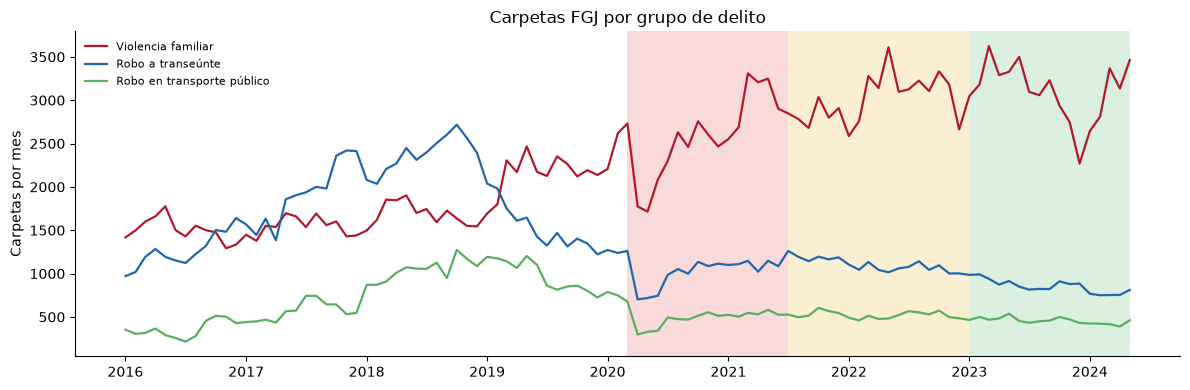

In [12]:
PERIODOS_COLOR = [("2020-03-01", "2021-06-30", "#f4b6b6"), ("2021-07-01", "2022-12-31", "#f9e0a8"), ("2023-01-01", "2026-07-31", "#b9e0c3")]

def sombrear(ax, fin):
    for a, b, c in PERIODOS_COLOR:
        ax.axvspan(pd.Timestamp(a), min(pd.Timestamp(b), fin), color=c, alpha=.5, lw=0)

serie = (fgj_mes[~fgj_mes.mes_incompleto]
         .pivot_table(index="mes", columns="grupo_delito", values="carpetas", aggfunc="sum"))
fig, ax = plt.subplots(figsize=(12, 4))
sombrear(ax, serie.index.max())
for g, c, l in [("violencia_familiar", "#b2182b", "Violencia familiar"),
                ("robo_transeunte", "#2166ac", "Robo a transeúnte"),
                ("robo_transporte_publico", "#5aae61", "Robo en transporte público")]:
    ax.plot(serie.index, serie[g], color=c, lw=1.6, label=l)
ax.set_ylabel("Carpetas por mes"); ax.set_title("Carpetas FGJ por grupo de delito")
ax.legend(frameon=False, fontsize=8, loc="upper left"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Lectura:** la violencia familiar bajó en abril de 2020 (el confinamiento dificultó denunciar) y luego subió con fuerza. El robo a transeúnte cayó y no se ha recuperado, aunque **ya venía bajando desde finales de 2018**, así que no toda la caída se debe a la pandemia.

### 2. Afluencia del Metrobús

**Decisiones de limpieza:**
- En 2023 las líneas venían como `linea N` y en los demás años como `Línea N`: se unificaron (14 → 7 líneas).
- Los vacíos **antes de que se inaugurara cada línea** no son datos faltantes (la línea no existía): se marcan con `linea_operando = False`.
- Los días atípicos se compararon con la mediana móvil de 29 días. Los que corresponden a eventos reales (sismo 19-S, elecciones, festivos, domingos) **se conservan**; solo se anularon 2 errores evidentes.
- 57 valores con decimales (Línea 4, ene–feb 2025) parecen estimaciones del Metrobús: se redondean y se marcan.

In [13]:
display(Markdown((DOCS / "limpieza_metrobus.md").read_text(encoding="utf-8")))

# Limpieza de afluencia del Metrobús

Generado por `src/clean/metrobus.py`.

## Pasos

| Paso | Resultado |
|---|---|
| Registros leídos (fecha × línea) | 53,732 |
| Nombres de línea distintos → unificados | 14 → 7 |
| Filas antes de la inauguración de su línea (no son faltantes) | 17,227 |
| Faltantes con la línea operando | 0 |
| Duplicados fecha × línea | 0 |
| Días atípicos (> 2.5× o < 0.2× la mediana de 29 días) | 30 (se conservan salvo errores evidentes) |
| Errores evidentes anulados | 2 |
| Valores con decimales (probables estimaciones; se redondean y marcan) | 57 |

## Errores anulados

| Fecha | Línea | Motivo |
|---|---|---|
| 2005-07-26 | Línea 1 | 3.03 M: ~13 veces un día normal; probable acumulado desde la inauguración |
| 2017-09-20 | Línea 2 | 9 pasajeros el día posterior al sismo 19-S; dato imposible o servicio suspendido |

## Días atípicos conservados (eventos reales)

| Fecha | Línea | Afluencia | × mediana |
|---|---|---:|---:|
| 2006-01-01 | Línea 1 | 28080 | 0.17 |
| 2006-01-15 | Línea 1 | 42586 | 0.189 |
| 2006-01-22 | Línea 1 | 43662 | 0.188 |
| 2006-01-29 | Línea 1 | 40194 | 0.17 |
| 2006-04-14 | Línea 1 | 37144 | 0.154 |
| 2012-12-01 | Línea 4 | 4930 | 0.092 |
| 2013-02-03 | Línea 4 | 3149 | 0.063 |
| 2013-06-02 | Línea 4 | 8599 | 0.192 |
| 2013-06-30 | Línea 4 | 9954 | 0.199 |
| 2013-07-07 | Línea 4 | 8266 | 0.188 |
| 2013-07-14 | Línea 4 | 5798 | 0.152 |
| 2013-07-21 | Línea 4 | 5446 | 0.151 |
| 2013-07-28 | Línea 4 | 5381 | 0.149 |
| 2013-08-04 | Línea 4 | 4944 | 0.134 |
| 2013-09-01 | Línea 4 | 2865 | 0.099 |
| 2013-09-08 | Línea 4 | 2748 | 0.106 |
| 2013-09-15 | Línea 4 | 6102 | 0.186 |
| 2016-02-12 | Línea 4 | 9395 | 0.164 |
| 2016-02-13 | Línea 4 | 6385 | 0.112 |
| 2017-09-20 | Línea 6 | 22550 | 0.11 |
| 2018-07-01 | Línea 7 | 14427 | 0.142 |
| 2019-09-16 | Línea 4 | 10854 | 0.15 |
| 2020-09-16 | Línea 4 | 6238 | 0.148 |
| 2020-12-25 | Línea 4 | 7544 | 0.191 |
| 2021-01-01 | Línea 4 | 7756 | 0.197 |
| 2023-12-31 | Línea 7 | 25208 | 0.198 |
| 2024-10-01 | Línea 4 | 12394 | 0.124 |
| 2026-01-01 | Línea 4 | 12697 | 0.155 |

## Afluencia diaria promedio por año

| Año | Viajes/día | Índice 2019=100 |
|---|---:|---:|
| 2005 | 194,766 | 16.0 |
| 2006 | 203,388 | 16.7 |
| 2007 | 212,749 | 17.5 |
| 2008 | 245,220 | 20.1 |
| 2009 | 348,482 | 28.6 |
| 2010 | 375,214 | 30.8 |
| 2011 | 512,607 | 42.1 |
| 2012 | 601,831 | 49.4 |
| 2013 | 630,223 | 51.8 |
| 2014 | 710,356 | 58.3 |
| 2015 | 757,588 | 62.2 |
| 2016 | 957,497 | 78.6 |
| 2017 | 1,009,578 | 82.9 |
| 2018 | 1,128,730 | 92.7 |
| 2019 | 1,217,528 | 100.0 |
| 2020 | 659,216 | 54.1 |
| 2021 | 846,008 | 69.5 |
| 2022 | 1,199,583 | 98.5 |
| 2023 | 1,374,622 | 112.9 |
| 2024 | 1,447,743 | 118.9 |
| 2025 | 1,397,520 | 114.8 |
| 2026 | 1,370,420 | 112.6 |

Nota: la red creció (Línea 6 en 2016, Línea 7 en 2018 y ampliaciones posteriores), así que
parte del aumento posterior a 2022 refleja más cobertura y no solo más demanda.


In [14]:
mb_dia = pd.read_csv(INTERIM / "metrobus_linea_dia.csv", parse_dates=["fecha"])
print(f"{len(mb_dia):,} filas (fecha × línea) · líneas: {sorted(mb_dia.linea.unique())}")
mb_dia.head()

53,732 filas (fecha × línea) · líneas: ['Línea 1', 'Línea 2', 'Línea 3', 'Línea 4', 'Línea 5', 'Línea 6', 'Línea 7']


,fecha,linea,afluencia,linea_operando,atipico,ratio_mediana,valor_estimado,error_corregido
0,2005-07-26,Línea 1,NaN,True,True,12.78,False,3.03 M: ~13 veces un día normal; probable acum...
1,2005-07-26,Línea 2,NaN,False,False,NaN,False,NaN
2,2005-07-26,Línea 3,NaN,False,False,NaN,False,NaN
3,2005-07-26,Línea 4,NaN,False,False,NaN,False,NaN
4,2005-07-26,Línea 5,NaN,False,False,NaN,False,NaN


In [15]:
# Faltantes reales: días en que la línea ya operaba pero no hay dato
operando = mb_dia[mb_dia.linea_operando]
print("Vacíos con la línea operando:", operando.afluencia.isna().sum(), "(son los 2 errores anulados)")
print("Días faltantes en el calendario:",
      len(pd.date_range(mb_dia.fecha.min(), mb_dia.fecha.max()).difference(mb_dia.fecha.unique())))
mb_dia[mb_dia.error_corregido.fillna("") != ""]

Vacíos con la línea operando: 2 (son los 2 errores anulados)
Días faltantes en el calendario: 0


,fecha,linea,afluencia,linea_operando,atipico,ratio_mediana,valor_estimado,error_corregido
0,2005-07-26,Línea 1,NaN,True,True,12.78,False,3.03 M: ~13 veces un día normal; probable acum...
31074,2017-09-20,Línea 2,NaN,True,True,0.00,False,9 pasajeros el día posterior al sismo 19-S; da...


In [16]:
mb_mes = pd.read_csv(INTERIM / "metrobus_mes.csv", parse_dates=["mes"])
mb_mes.tail()

,mes,afluencia_total,lineas_operando,dias_con_dato,afluencia_diaria_promedio,linea_1,linea_2,linea_3,linea_4,linea_5,linea_6,linea_7
248,2026-03-01,44002655,7,31,1419440.0,13430056,5895678.0,5213618.0,2612766.0,7608767.0,5678821.0,3562949.0
249,2026-04-01,42149475,7,30,1404982.0,12905050,5625436.0,5147879.0,2640207.0,7152323.0,5175651.0,3502929.0
250,2026-05-01,43122913,7,31,1391062.0,12898988,5956492.0,5271974.0,2570282.0,7491785.0,5530040.0,3403352.0
251,2026-06-01,39751764,7,30,1325059.0,12372400,5622688.0,4906584.0,1102181.0,7262320.0,5574803.0,2910788.0
252,2026-07-01,40771965,7,31,1315225.0,12361362,5325716.0,5081193.0,2559613.0,7000955.0,5238929.0,3204197.0


#### Metro frente a Metrobús (índice 2019 = 100)

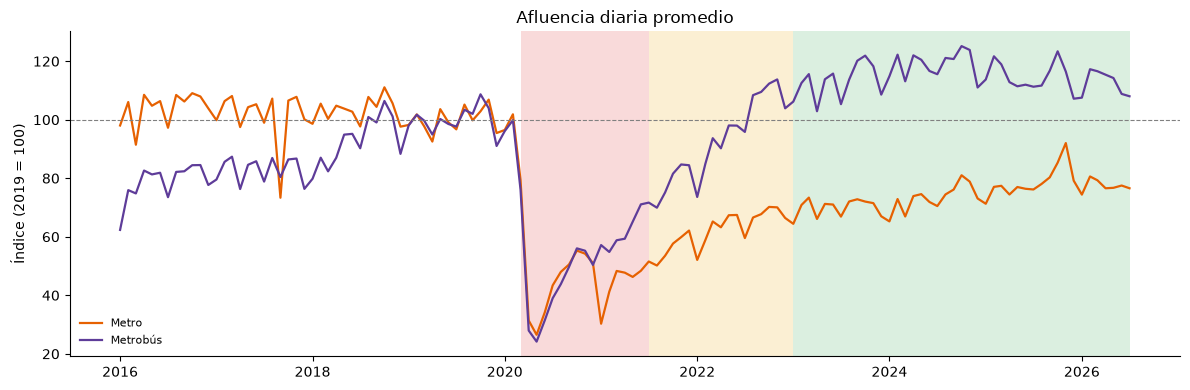

,Metro,Metrobús
2016,104.0,78.6
2017,101.3,82.9
2018,103.3,92.7
2019,100.0,100.0
2020,56.0,54.1
2021,49.8,69.5
2022,64.6,98.5
2023,69.9,112.9
2024,73.3,118.9
2025,78.7,114.8


In [17]:
metro = pd.read_csv(RAW / "metro" / "afluencia_metro_simple.csv", parse_dates=["fecha"])
metro_mes = metro.set_index("fecha").afluencia.resample("MS").sum()
metro_mes = metro_mes / metro_mes.index.days_in_month          # promedio diario del mes
mb = mb_mes.set_index("mes").afluencia_diaria_promedio

idx_metro = (metro_mes / metro_mes["2019"].mean() * 100)["2016":]
idx_mb = (mb / mb["2019"].mean() * 100)["2016":]

fig, ax = plt.subplots(figsize=(12, 4))
sombrear(ax, idx_mb.index.max())
ax.plot(idx_metro.index, idx_metro, color="#e66101", lw=1.6, label="Metro")
ax.plot(idx_mb.index, idx_mb, color="#5e3c99", lw=1.6, label="Metrobús")
ax.axhline(100, color="grey", lw=.8, ls="--")
ax.set_ylabel("Índice (2019 = 100)"); ax.set_title("Afluencia diaria promedio")
ax.legend(frameon=False, fontsize=8, loc="lower left"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

pd.DataFrame({"Metro": idx_metro.groupby(idx_metro.index.year).mean(),
              "Metrobús": idx_mb.groupby(idx_mb.index.year).mean()}).round(1)

**Lectura:** los dos sistemas cayeron ~75 % en mayo de 2020, pero el Metrobús ya supera su nivel de 2019 mientras el Metro sigue en 73–79. Posibles causas: la ampliación de la red del Metrobús y el traslado de usuarios por los cierres de las Líneas 1 y 12 del Metro.